

Denne skabelon indeholder fire sektioner: **Opgave 1** til **Opgave 4**. Hver sektion har fire underspørgsmål: **Spørgsmål 1** til **Spørgsmål 4**.
En notebook konverteres til pdf ved at køre: jupyter nbconvert --to pdf ExamTemplate2026.ipynb i terminalen.
Når notebooken eksporteres/printes til PDF, starter hver ny opgave på en ny side.


<style>
@media print {
  .pagebreak { page-break-before: always; break-before: page; }
}
</style>


## Kopiérbar blok til indsættelse af billeder

### Markdown-metode
Kopiér linjen nedenfor til en Markdown-celle og ret filnavn/størrelse efter behov:

```markdown
<img src="images/dit_billede.png" alt="Kort beskrivelse" width="600">
```

### Python-metode
Kør kodecellen nedenfor, og brug funktionen `indsæt_billede(...)` i dine svar.


In [1]:
from IPython.display import Image, display

def indsæt_billede(sti, bredde=600):
    """Viser et billede i notebooken.

    Parametre:
    sti: Filsti til billedet, fx 'images/figur1.png'
    bredde: Billedets bredde i pixels, fx 600
    """
    display(Image(filename=sti, width=bredde))

# indsæt_billede('tree.png', bredde=600)


In [2]:
# Imports
import numpy as np
import pulp as PLP

# Opgave 1

Skriv din besvarelse nedenfor.


## Spørgsmål 1 / 2

The branch and bound method is used to solve integer linear programming problems (ILP) by iteratively restricting the feasible region of a linear programming relaxation of the problem. The method involves branching on decision variables, creating subproblems, and using bounds to eliminate subproblems that cannot yield better solutions than the best known solution. The process continues until all subproblems have been explored or eliminated, resulting in the optimal integer solution.

The inital tree we have been presented comese by first exploring the left tree by branching on the first non-01-integer variable found in the LP problem $P_0$, $x_2$. This then leads to a non-01integer solution on $x_3$, which is branched upon, leading to feasible solutions in $P_2$ and $P_3$. The best solution so far is noted to be $P_2$. Since these solutions are both feasible, we cannot further improve the solution by restricting the feasible space.

## Spørgsmål 3

Since $P_2$ and $P_3$ are both integer solutions we cannot further improve the left branch, as such we explore the right branch. To do so i constuct the ILP in PULP. I use a function i have made that solves the problems recursively for me using pulp:


In [3]:
import pulp as PLP
import numpy as np
from math import ceil, floor
import copy

def branch_and_bound(LPmodel, sense, best_so_far = [None], objectives = [None], problem = [0]):

    """
    :param LPmodel:
    input a Linear Programming relaxation of the ILP problem.
    Note it is import to keep track of if it is a minimization or maximization problem, as this will determine the
    branching strategy and pruning strategy.
    :return:
    Iterative Branch and Bound solution to the ILP problem.
    """
    if best_so_far[0] is None:
        if sense == "maximize":
            best_so_far[0] = -10 ** 6
        else:
            best_so_far[0] = 10 ** 6

    if sense != "maximize" and sense != "minimize":
        raise ValueError("sense must be either 'maximize' or 'minimize'")
    if sense == "maximize":
        def objective_is_not_better(obj):
            return obj < best_so_far[0]
    if sense == "minimize":
        def objective_is_not_better(obj):
            return obj > best_so_far[0]


    def is_integer_value():
        """
        :return:
        dict where keys are variable names and values are boolean values indicating whether variable is integer.
        """
        eps = 10**-4
        vars = LPmodel.variables()

        d = dict()
        # Assign boolean values to the decision variables based on whether they are integer or not
        for var in vars:
            if abs(var.varValue - ceil(var.varValue)) > eps and abs(var.varValue - floor(var.varValue)) > eps:
                d[var.name] = False
            else:
                d[var.name] = True
        return d
    print(20*"#")
    print("Problem : ", problem[0])
    print(20 * "#")
    print()
    ### Step 1 - Solve problem ###
    LPmodel.solve(PLP.PULP_CBC_CMD(msg = 0))
    obj = PLP.value(LPmodel.objective)
    ### Step 2 - Branch on non-integer decision variable
    vars = is_integer_value()
    if LPmodel.status == PLP.LpStatusInfeasible:
        print("Pruning branch, infeasible\n")
        return objectives
    if objective_is_not_better(obj):
        print("Pruning branch with objective value ", obj, " which is worse than best so far ", best_so_far[0])
        print("Decision variables: ")
        for v in LPmodel.variables():
            print(v.name, "=", v.varValue)
        print("Objective value: ", obj)
        print()
        return objectives
    if all([v for v in vars.values()]):
        print("Found feasible branch, backtracking")
        print("Decision variables: ")
        for v in LPmodel.variables():
            print(v.name, "=", v.varValue)
        print("Objective value: ", obj)
        print()
        if obj > best_so_far[0] and sense == "maximize":
            best_so_far[0] = obj
        if obj < best_so_far[0] and sense == "minimize":
            best_so_far[0] = obj
        objectives[0] = obj
        return objectives


    for name, value in vars.items():
        if value:
            continue
        else:
            branch_name = name
            branch_value = LPmodel.variablesDict()[branch_name].varValue
            break
    ### Step 3 - Create two branches and solve recursively ###
    ### Base case - All decision variables or the problem is not feasible or objective does not become better ###


    # Left branch
    left_model = copy.deepcopy(LPmodel)
    left_model += left_model.variablesDict()[branch_name] <= floor(branch_value)

    for v in LPmodel.variables():
        print(v.name, "=", v.varValue)
    print("Objective: ", obj)
    print("Adding constraint ", branch_name, " <= ", floor(branch_value), " to left branch")
    print()
    problem[0] = problem[0] + 1
    branch_and_bound(left_model, sense, best_so_far, objectives, problem)

    # Right branch
    right_model = copy.deepcopy(LPmodel)
    right_model += right_model.variablesDict()[branch_name] >= ceil(branch_value)
    print("Adding constraint ", branch_name, " >= ", ceil(branch_value), " to right branch")
    print()
    problem[0] = problem[0] + 1
    branch_and_bound(right_model, sense, best_so_far, objectives, problem)

    return best_so_far[0]

In [4]:
x_range = range(5)
x = PLP.LpVariable.dicts("x", indices=x_range, cat = PLP.LpContinuous, lowBound=0, upBound=1)
model = PLP.LpProblem("ILP", sense=PLP.LpMaximize)

#Objective
obj_coef = [6,6,4,7,1]
model += PLP.lpSum(obj_coef[i]*x[i] for i in x_range)

#Constraint 1
c1_coef = [3,2,5,5,6]
model += PLP.lpSum(c1_coef[i]*x[i] for i in x_range) <= 14

# Constraint 2
c2_coef = [4,5,3,7,2]
model += PLP.lpSum(c2_coef[i]*x[i] for i in x_range) <= 15

# Constraint 3
c3_coef = [3,4,7,4,1]
model += PLP.lpSum(c3_coef[i]*x[i] for i in x_range) <= 10
# Add current constraint for right branch from root node
model += x[1] >= 1
# solve
model.solve()

branch_and_bound(model, sense= "maximize")
print()


####################
Problem :  0
####################

x_0 = 1.0
x_1 = 1.0
x_2 = 0.0
x_3 = 0.75
x_4 = 0.0
Objective:  17.25
Adding constraint  x_3  <=  0  to left branch

####################
Problem :  1
####################

x_0 = 1.0
x_1 = 1.0
x_2 = 0.28571429
x_3 = 0.0
x_4 = 1.0
Objective:  14.14285716
Adding constraint  x_2  <=  0  to left branch

####################
Problem :  2
####################

Found feasible branch, backtracking
Decision variables: 
x_0 = 1.0
x_1 = 1.0
x_2 = 0.0
x_3 = 0.0
x_4 = 1.0
Objective value:  13.0

Adding constraint  x_2  >=  1  to right branch

####################
Problem :  3
####################

Pruning branch, infeasible

Adding constraint  x_3  >=  1  to right branch

####################
Problem :  4
####################

x_0 = 0.66666667
x_1 = 1.0
x_2 = 0.0
x_3 = 1.0
x_4 = 0.0
Objective:  17.00000002
Adding constraint  x_0  <=  0  to left branch

####################
Problem :  5
####################

x_0 = 0.0
x_1 = 1.0
x_2 = 0.14285714


This leads to the tree starting from $P_4$, we find the optimal solution $z = 14$ in $P_{10}$. This is not unique, as this solution is also found in $P_2$, as such

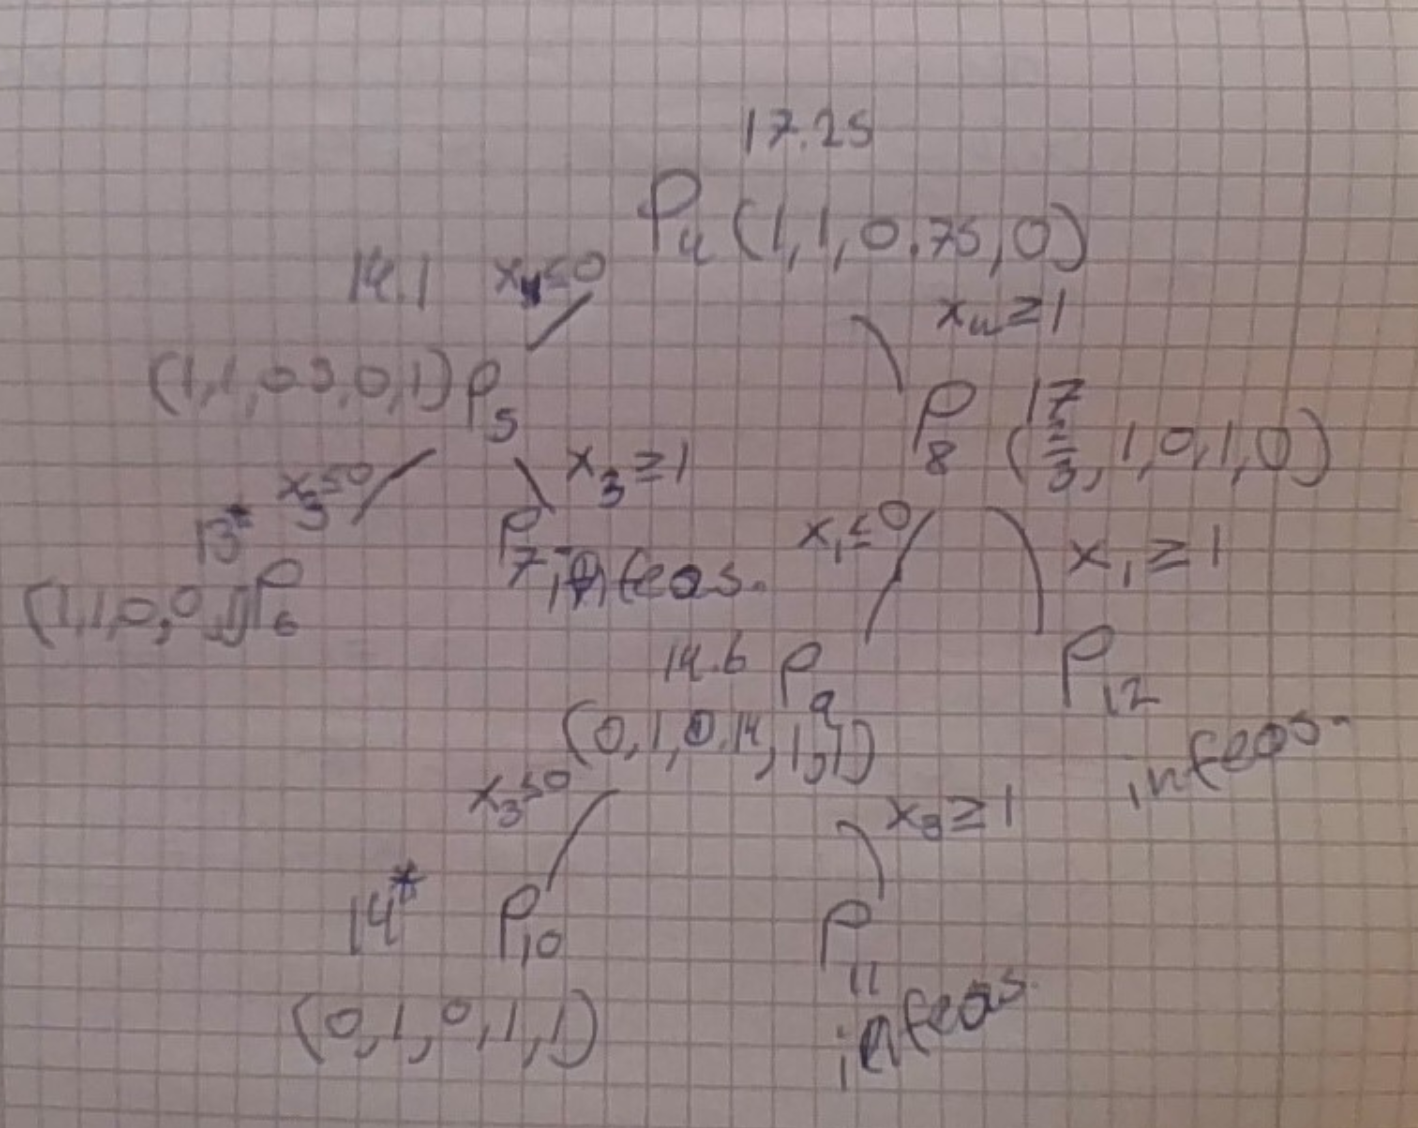

In [5]:
indsæt_billede("tree2024.png")

\newpage

# Opgave 2

Skriv din besvarelse nedenfor.


## Spørgsmål 1 / 2

From "Lifted Cover Inequalities: Padberg’s procedure" and "Heltalsmodeller" Uge 13.

Let variables $\delta_i \in \{0,1\}$, and coeffcients $a_i \in \mathbb{N}$ $i = 1...n$

and assume that we are looking at a knapsack inequality, that is, an inequality on the form:

$$\sum_{i=1}^n a_i\delta_i \leq a_0$$
We then define that $S \subseteq \{1,2, \dots, n\} = C$ and let $a(S) = \sum_{j \in S} a_j$. Then a cover is defined as a set $S$ such that $a(S) > a_0$. A cover inequality is then defined as:
$$\sum_{j \in S} \delta_j \leq |S| - 1$$
A minimal cover is then defined as a cover such that for all $i \in S$ we have that $a(S \setminus \{i\}) \leq a_0$. That is, we cannot remove any one element from the cover without it ceasing to be a cover.

From constraint 1 in the ILP in Opgave 1, we can derive the following minimal cover inequality:
$$\delta_3 + \delta_4 + \delta_5 \leq 2$$

From constraint 2 in the ILP in Opgave 1, we can derive the following minimal cover inequality:
$$\delta_1 + \delta_2 + \delta_4 \leq 2$$
From constraint 3 in the ILP in Opgave 1, we can derive the following minimal cover inequality:
$$\delta_3 + \delta_4 \leq 1$$


## Spørgsmål 3

We can build an extended cover inequality from a minimal cover $S$. We let $a^* = max(a_j \in S)$. Then without changing the right hands side of the corresponding minimal cover inequality induced by $S$, we can add $\delta_k$ variables where $k \notin S$ to the left hand side if and only if $a_k \geq a^*$.

To awnser if i can create an extented cover inequality, we check $a^*$ for the respective minimal covers:

For constraint 1:
$$a^* =a_5 = 6> a_i \forall \in C \setminus 5$$
So it follows that we cannot form an extended cover

For constraint 2:
$$a^* =a_4 = 7 >a_i \forall \in C \setminus 4$$
So it follows that we cannot form an extended cover

For constraint 3:
$$a^* =a_3 = 7> a_i \forall \in C \setminus 3$$
So it follows that we cannot form an extended cover


## Spørgsmål 4
We can use the thrid inequality to from this mentioned extended cover inequality. Let
$S = \{1,2,4\}$ define the minimal cover, then $a_3 > a^*$ and we can form the extended cover inequality.


## Spørgsmål 5

I reuse the code from Opgave 1, but with the extended cover inequality added, we see that branch and bound then finds the optimals solution in one iteration.


In [6]:
x_range = range(5)
x = PLP.LpVariable.dicts("x", indices=x_range, cat = PLP.LpContinuous, lowBound=0, upBound=1)
model = PLP.LpProblem("ILP", sense=PLP.LpMaximize)

#Objective
obj_coef = [6,6,4,7,1]
model += PLP.lpSum(obj_coef[i]*x[i] for i in x_range)

#Constraint 1
c1_coef = [3,2,5,5,6]
model += PLP.lpSum(c1_coef[i]*x[i] for i in x_range) <= 14

# Constraint 2
c2_coef = [4,5,3,7,2]
model += PLP.lpSum(c2_coef[i]*x[i] for i in x_range) <= 15

# Constraint 3
c3_coef = [3,4,7,4,1]
model += PLP.lpSum(c3_coef[i]*x[i] for i in x_range) <= 10
# Extended cover ineq.
model += x[0] + x[1] + x[2] + x[3] <= 2
# solve
model.solve()

branch_and_bound(model, sense= "maximize")


####################
Problem :  8
####################

Found feasible branch, backtracking
Decision variables: 
x_0 = 0.0
x_1 = 1.0
x_2 = 0.0
x_3 = 1.0
x_4 = 1.0
Objective value:  14.0



[14.0]

\newpage

# Opgave 3



## Spørgsmål 1

Below i have implemented a class that models the STSP-DJF. We can model this problem as a symmetric problem, because when we use the straight line distance between two points, the distance is the same wether we go from point i to j or j to i. Explainations are left as comments in the code


In [7]:
import pulp as PLP
import numpy as np
import itertools

class symmetric_tsp_dfj:
    """ This implementation of the symmetric TSP DFJ problem follows from
    the slipes in uge 10, TSP-formuleringer (pdf), slides 7 - 10"""

    def __init__(self, n, cost_matrix = None, x_coords = None, y_coords = None):
        self.n = n
        self.cost_matrix = cost_matrix

        if x_coords is not None and y_coords is not None and cost_matrix is None:
            self.cost_matrix = self.cost_from_coordinates(x_coords, y_coords)

        # ILP problem
        self.model = PLP.LpProblem(name = "SymmetricTSP_DFJ", sense = PLP.LpMinimize)
        # Define arcs,
        self.arcs = [(i,j) for i in range(n) for j in range(n) if i < j]
        # Definte subsets
        self.S = self.define_subsets()

        #### Variable definition ####
        # Binary variable indicating whether arc (i,j) is used in the solution
        self.x = PLP.LpVariable.dicts("x", self.arcs, lowBound=0, upBound=1, cat=PLP.LpBinary)

        #### Obejctive function ####
        self.model += PLP.lpSum(self.cost_matrix[i][j] * self.x[(i, j)] for i, j in self.arcs), "Objective"


    def define_constraints(self):

        ### CONSTRAINTS ###

        # Valence contraint, makes sure that each point it connected to two other points
        for j in range(self.n):
            self.model += PLP.lpSum(self.x[(i, j)] for i in range(j)) + \
                          PLP.lpSum(self.x[(j, i)] for i in range(j + 1, self.n)) \
                          == 2, f"valence{j}"

        # Subtour elimination, DFJ uses subsets and we restrict the solution such that
        # There does not exist a S subset of {0, 1, 2, ..., n - 1 } such there is a closed
        # loops in the solution in the vertices contained in S
        # The degree constraints ensure that every city has exactly two incident edges,
        # which means each city is entered once and left once
        for k, s in enumerate(self.S):
            self.model += PLP.lpSum(self.x[(i, j)] for i in s for j in s if i < j) <= len(
                s) - 1, f"SubtourElimination{k}"
        self.constraints = "Added"

    def cost_from_coordinates(self, x_cords, y_cords):
        # Computes L2 distance between points, this can serve as a cost.
        n = len(x_cords)
        cost_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i == j:
                    # Set diagonal to very large number
                    very_large_number = 10 ** 6
                    cost_matrix[i][j] = very_large_number
                else:
                    diff_x = x_cords[i] - x_cords[j]
                    diff_y = y_cords[i] - y_cords[j]
                    dist = np.sqrt(diff_x ** 2 + diff_y ** 2)
                    cost_matrix[i][j] = dist
        return cost_matrix

    def define_subsets(self):
        S = []
        for cardinality in range(3, self.n - 3 + 1):
            # Finds all combinations of the cardinality
            subset = itertools.combinations(list(range(self.n)), cardinality)
            # Return the set
            subset = set(subset)
            # Add the subset to S
            S = S + list(subset)
        return S

    def solve_and_print(self, one_indexed = True, quiet = True):
        ### SOLVE ###
        if self.constraints is None:
            raise Exception("You must define the constraints before solving, call define_constraints() method")

        self.model.solve(PLP.PULP_CBC_CMD(msg = 0 if quiet else 1))
        print("Status:", PLP.LpStatus[self.model.status])
        print("Objective value:", PLP.value(self.model.objective))
        for arc in self.arcs:
            if self.x[arc].varValue > 0.5:
                print(f"Arc ({arc[0] + (1 if one_indexed else 0)}, {arc[1] + (1 if one_indexed else 0)}) is in the"
                      f" solution with cost {round(self.cost_matrix[arc[0]][arc[1]],2)}")

if __name__ == "__main__":
    # Eksamen 2024 as an example
    x_coords = "2.0 2.5 2.8 1.0 1.5 2.0 1.5 7.0 7.3 7.9 8.2 7.6".split(" ")
    x_coords = [float(v) for v in x_coords]
    y_coords = "3.0 3.5 2.7 8.0 8.5 8.0 7.5 5.0 5.4 5.6 5.0 4.5".split(" ")
    y_coords = [float(v) for v in y_coords]
    n = len(x_coords)

    # Overwrite such that there is not subtour elimination constraints (SEC)
    print("Spm. 2")
    STSP = symmetric_tsp_dfj(n, x_coords=x_coords, y_coords=y_coords)
    STSP.S = []
    STSP.define_constraints()
    STSP.solve_and_print(quiet = True)

    print("Spm. 3")
    STSPrelaxed = symmetric_tsp_dfj(n, x_coords=x_coords, y_coords=y_coords)
    STSPrelaxed.S = [(range(3)), range(3, 7), range(7, 12)]
    STSPrelaxed.define_constraints()
    STSPrelaxed.solve_and_print(quiet = True)
    # Print the subtour elimination constraints
    for name, constraint in STSPrelaxed.model.constraints.items():
        if "Subtour" in name:
            print(name, " : ", constraint)

    print("Spm. 4")
    # We can compare to the solution where we add just S_2 to the solution from Spm 2.
    SPSTS_S2 = symmetric_tsp_dfj(n, x_coords=x_coords, y_coords=y_coords)
    SPSTS_S2.S = [range(3, 7)] # Zero indexed - 3, 4, 5, 6
    SPSTS_S2.define_constraints()
    SPSTS_S2.solve_and_print(quiet = True)
    for name, constraint in SPSTS_S2.model.constraints.items():
        if "Subtour" in name:
            print(name, " : ", constraint)





Spm. 2
Status: Optimal
Objective value: 8.609660515461186
Arc (1, 2) is in the solution with cost 0.71
Arc (1, 3) is in the solution with cost 0.85
Arc (2, 3) is in the solution with cost 0.85
Arc (4, 5) is in the solution with cost 0.71
Arc (4, 7) is in the solution with cost 0.71
Arc (5, 6) is in the solution with cost 0.71
Arc (6, 7) is in the solution with cost 0.71
Arc (8, 9) is in the solution with cost 0.5
Arc (8, 12) is in the solution with cost 0.78
Arc (9, 10) is in the solution with cost 0.63
Arc (10, 11) is in the solution with cost 0.67
Arc (11, 12) is in the solution with cost 0.78
Spm. 3
Status: Optimal
Objective value: 21.347588159805703
Arc (1, 2) is in the solution with cost 0.71
Arc (1, 3) is in the solution with cost 0.85
Arc (2, 7) is in the solution with cost 4.12
Arc (3, 12) is in the solution with cost 5.13
Arc (4, 5) is in the solution with cost 0.71
Arc (4, 7) is in the solution with cost 0.71
Arc (5, 6) is in the solution with cost 0.71
Arc (6, 8) is in the s

## Spørgsmål 2

We solve the model with no subtour elemination contraints:


In [8]:

x_coords = "2.0 2.5 2.8 1.0 1.5 2.0 1.5 7.0 7.3 7.9 8.2 7.6".split(" ")
x_coords = [float(v) for v in x_coords]
y_coords = "3.0 3.5 2.7 8.0 8.5 8.0 7.5 5.0 5.4 5.6 5.0 4.5".split(" ")
y_coords = [float(v) for v in y_coords]
n = len(x_coords)
# Overwrite such that there is not subtour elimination constraints (SEC)
STSP = symmetric_tsp_dfj(n, x_coords=x_coords, y_coords=y_coords)
STSP.S = []
STSP.define_constraints()
STSP.solve_and_print(quiet = True)

Status: Optimal
Objective value: 8.609660515461186
Arc (1, 2) is in the solution with cost 0.71
Arc (1, 3) is in the solution with cost 0.85
Arc (2, 3) is in the solution with cost 0.85
Arc (4, 5) is in the solution with cost 0.71
Arc (4, 7) is in the solution with cost 0.71
Arc (5, 6) is in the solution with cost 0.71
Arc (6, 7) is in the solution with cost 0.71
Arc (8, 9) is in the solution with cost 0.5
Arc (8, 12) is in the solution with cost 0.78
Arc (9, 10) is in the solution with cost 0.63
Arc (10, 11) is in the solution with cost 0.67
Arc (11, 12) is in the solution with cost 0.78


We see that we get the arcs $(1,2),(1,3),(2,3)$, thus the subtour $S_1$

We see that we get the arcs $(4,5),(4,7),(5,6),(6,7)$ thus the subtour $S_2$

We see that we get the arcs $(8,9),(8,12),(9,10),(10,11),(11,12)$ thus the subtour $S_3$

## Spørgsmål 3


In [9]:
STSPrelaxed = symmetric_tsp_dfj(n, x_coords=x_coords, y_coords=y_coords)
STSPrelaxed.S = [(range(3)), range(3, 7), range(7, 12)]
STSPrelaxed.define_constraints()
STSPrelaxed.solve_and_print(quiet = True)
# Print the subtour elimination constraints
for name, constraint in STSPrelaxed.model.constraints.items():
    if "Subtour" in name:
        print(name, " : ", constraint)

Status: Optimal
Objective value: 21.347588159805703
Arc (1, 2) is in the solution with cost 0.71
Arc (1, 3) is in the solution with cost 0.85
Arc (2, 7) is in the solution with cost 4.12
Arc (3, 12) is in the solution with cost 5.13
Arc (4, 5) is in the solution with cost 0.71
Arc (4, 7) is in the solution with cost 0.71
Arc (5, 6) is in the solution with cost 0.71
Arc (6, 8) is in the solution with cost 5.83
Arc (8, 9) is in the solution with cost 0.5
Arc (9, 10) is in the solution with cost 0.63
Arc (10, 11) is in the solution with cost 0.67
Arc (11, 12) is in the solution with cost 0.78
SubtourElimination0  :  x_(0,_1) + x_(0,_2) + x_(1,_2) <= 2.0
SubtourElimination1  :  x_(3,_4) + x_(3,_5) + x_(3,_6) + x_(4,_5) + x_(4,_6) + x_(5,_6) <= 3.0
SubtourElimination2  :  x_(10,_11) + x_(7,_10) + x_(7,_11) + x_(7,_8) + x_(7,_9) + x_(8,_10) + x_(8,_11) + x_(8,_9) + x_(9,_10) + x_(9,_11) <= 4.0


We can extract the constraints from the models. From $S_1$ we get 3 variables which are variables:
$$x_{01} + x_{02} + x_{12}$$

From $S_2$ we get 6 variables which are:
$$x_{34} + x_{35} + x_{36} + x_{45} + x_{46} + x_{56}$$



## Spørgsmål 4
Since the subtour elimination constraints removes all of the mentioned subtours, since the constraint allows for at most 3 edges in the set of nodes defines by $S_2$
We also see from that model output that all of the subtours are eliminated.


In [10]:
# Beregninger/kode til dette spørgsmål kan skrives her
# We can compare to the solution where we add just S_2 to the solution from Spm 2.
SPSTS_S2 = symmetric_tsp_dfj(n, x_coords=x_coords, y_coords=y_coords)
SPSTS_S2.S = [range(3, 7)] # Zero indexed - 3, 4, 5, 6
SPSTS_S2.define_constraints()
SPSTS_S2.solve_and_print(quiet = True)
for name, constraint in SPSTS_S2.model.constraints.items():
    if "Subtour" in name:
        print(name, " : ", constraint)

Status: Optimal
Objective value: 16.139138366587915
Arc (1, 3) is in the solution with cost 0.85
Arc (1, 7) is in the solution with cost 4.53
Arc (2, 3) is in the solution with cost 0.85
Arc (2, 7) is in the solution with cost 4.12
Arc (4, 5) is in the solution with cost 0.71
Arc (4, 6) is in the solution with cost 1.0
Arc (5, 6) is in the solution with cost 0.71
Arc (8, 9) is in the solution with cost 0.5
Arc (8, 12) is in the solution with cost 0.78
Arc (9, 10) is in the solution with cost 0.63
Arc (10, 11) is in the solution with cost 0.67
Arc (11, 12) is in the solution with cost 0.78
SubtourElimination0  :  x_(3,_4) + x_(3,_5) + x_(3,_6) + x_(4,_5) + x_(4,_6) + x_(5,_6) <= 3.0


## Spørgsmål 5
We solve the model using all contraints. We see that we get a model with no subtours, and thus a optimal solution to the STSP


In [11]:
STSPrelaxed = symmetric_tsp_dfj(n, x_coords=x_coords, y_coords=y_coords)
STSPrelaxed.S = [(range(3)), range(3, 7), range(7, 12)]
STSPrelaxed.define_constraints()
STSPrelaxed.solve_and_print(quiet = True)


Status: Optimal
Objective value: 21.347588159805703
Arc (1, 2) is in the solution with cost 0.71
Arc (1, 3) is in the solution with cost 0.85
Arc (2, 7) is in the solution with cost 4.12
Arc (3, 12) is in the solution with cost 5.13
Arc (4, 5) is in the solution with cost 0.71
Arc (4, 7) is in the solution with cost 0.71
Arc (5, 6) is in the solution with cost 0.71
Arc (6, 8) is in the solution with cost 5.83
Arc (8, 9) is in the solution with cost 0.5
Arc (9, 10) is in the solution with cost 0.63
Arc (10, 11) is in the solution with cost 0.67
Arc (11, 12) is in the solution with cost 0.78
